In [ ]:
# ==============================================================================
# PROJECT: SMART MENTAL HEALTH COUNSELLING & RISK PREDICTION SYSTEM
# PURPOSE: Unified Training, Testing, and Analytics Pipeline
# AUTHOR: HASHMIL MUHAMMED
# ==============================================================================

# --- [DEPENDENCY INSTALLATION] ---
# !pip install -U catboost
# pip install pandas matplotlib

# --- 1. CORE DATA OPERATIONS ---
import pandas as pd  # Primary tool for structured data manipulation (DataFrames)
import numpy as np   # Fundamental package for numerical arrays and math operations

# --- 2. SYSTEM & ENVIRONMENT CONFIGURATION ---
import warnings      # Manage system-generated warnings
warnings.filterwarnings('ignore')  # Ensure a clean console output by hiding non-critical warnings

# --- 3. STATISTICAL DATA VISUALIZATION ---
import seaborn as sns             # Statistical data visualization based on matplotlib
import matplotlib.pyplot as plt    # Core plotting engine for generating static charts
import plotly.express as px        # High-level interface for interactive data exploration
import plotly.graph_objects as go  # Low-level interface for complex interactive figures
import plotly.figure_factory as ff # Factory for specialized plots (e.g., Distplots, Dendrograms)
from termcolor import colored      # Enhancement for terminal output readability

# --- 4. DATA ENGINEERING & PREPROCESSING ---
from sklearn.model_selection import train_test_split # Logic for splitting dataset into Train/Test subsets
from sklearn.preprocessing import LabelEncoder       # Transforms categorical text into numerical labels

# --- 5. CLASSIFICATION ALGORITHM SUITE ---
from sklearn.linear_model import LogisticRegression     # Baseline linear model for classification
from sklearn.ensemble import RandomForestClassifier     # Bagging ensemble of Decision Trees
from sklearn.ensemble import GradientBoostingClassifier  # Sequential boosting for error reduction
from xgboost import XGBClassifier                        # Scalable, portable, and distributed gradient boosting
# from catboost import CatBoostClassifier                  # High-performance boosting for categorical features

# --- 6. MODEL PERFORMANCE METRICS ---
from sklearn.metrics import accuracy_score       # Metric: (TP+TN) / Total population
from sklearn.metrics import classification_report # Comprehensive summary (Precision, Recall, F1)
from sklearn.metrics import confusion_matrix      # Matrix to evaluate classification accuracy per label

# --- 7. DEPLOYMENT & PERSISTENCE ---
import joblib  # Efficient serialization for saving/loading trained ML models

# --- 8. INTERACTIVE UI & ANALYTICS ---
import ipywidgets as widgets            # Toolkit for building interactive notebook dashboards
from IPython.display import display, clear_output # Dynamic rendering of UI components
from datetime import datetime           # Handling timestamps for session history and logging


from google.colab import files


In [ ]:
import numpy
import sklearn
import joblib
import pandas
import platform

print(f"{'='*30}")
print("🧠 Project Environment Check")
print(f"{'='*30}")
print(f"Python Version: {platform.python_version()}")
print(f"NumPy Version:  {numpy.__version__}")
print(f"Scikit-Learn:   {sklearn.__version__}")
print(f"Joblib Version: {joblib.__version__}")
print(f"Pandas Version: {pandas.__version__}")
print(f"{'='*30}")

# Warning logic for your specific model error
if int(numpy.__version__.split('.')[0]) >= 2:
    print("⚠️ WARNING: NumPy 2.0+ detected. This may cause 'BitGenerator' errors with your .pkl files.")
    print("👉 Fix: Run '!pip install \"numpy<2.0.0\"' and restart the session.")
else:
    print("✅ NumPy version is compatible (1.x).")

🧠 Project Environment Check
Python Version: 3.12.12
NumPy Version:  2.0.2
Scikit-Learn:   1.6.1
Joblib Version: 1.5.3
Pandas Version: 2.2.2
⚠️ WARNING: NumPy 2.0+ detected. This may cause 'BitGenerator' errors with your .pkl files.
👉 Fix: Run '!pip install "numpy<2.0.0"' and restart the session.


# **PHASE 1: DATA ACQUISITION & INITIAL EXPLORATION**

**--- DATASET LOADING ---**

In [ ]:

# Path: /content/Behaviour_Risk_Dataset.csv
# Reading the raw CSV data into a Pandas DataFrame structure
try:
    df = pd.read_csv("/content/Behaviour_Risk_Dataset.csv")
    print(colored("✅ Dataset loaded successfully!", "green", attrs=["bold"]))
except FileNotFoundError:
    print(colored("❌ Error: Dataset file not found. Check the path.", "red"))

✅ Dataset loaded successfully!


**--- PREVIEWING THE DATA STRUCTURE ---**

In [ ]:

# Displaying the first 5 rows to inspect column alignment and initial values
print("\n--- [TOP 5 RECORDS] ---")
display(df.head())


--- [TOP 5 RECORDS] ---


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Behaviour_Risk
0,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,High
1,287,Female,50,Nurse,6.0,6,90,8,Overweight,140/95,75,10000,High
2,49,Male,31,Doctor,7.7,7,75,6,Healthy Weight,120/80,70,8000,Low
3,231,Female,44,Teacher,6.6,7,45,4,Overweight,135/90,65,6000,Medium
4,107,Female,37,Nurse,6.1,6,42,6,Overweight,126/83,77,4200,Low


# **PHASE 2: STRUCTURAL ANALYSIS & STATISTICAL PROFILING**

**--- DATASET DIMENSIONS ---**

In [ ]:
# Validating memory usage, data types (int/float/object), and identifying missing entries
print('The dimention of data is :',df.shape)

# Checking the total number of entries (rows) and features (columns)
print(f"\n📊 Dataset Dimensions: {df.shape[0]} Rows | {df.shape[1]} Columns")

The dimention of data is : (1200, 13)

📊 Dataset Dimensions: 1200 Rows | 13 Columns


**--- DATATYPE & NULL-VALUE INSPECTION ---**

In [ ]:
# Validating memory usage, data types (int/float/object), and identifying missing entries
print(colored("--- [DATASET ARCHITECTURE & INTEGRITY] ---", "blue", attrs=["bold"]))
df.info()

--- [DATASET ARCHITECTURE & INTEGRITY] ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                1200 non-null   int64  
 1   Gender                   1200 non-null   object 
 2   Age                      1200 non-null   int64  
 3   Occupation               1200 non-null   object 
 4   Sleep Duration           1200 non-null   float64
 5   Quality of Sleep         1200 non-null   int64  
 6   Physical Activity Level  1200 non-null   int64  
 7   Stress Level             1200 non-null   int64  
 8   BMI Category             1200 non-null   object 
 9   Blood Pressure           1200 non-null   object 
 10  Heart Rate               1200 non-null   int64  
 11  Daily Steps              1200 non-null   int64  
 12  Behaviour_Risk           1200 non-null   object 
dtypes: float64(1), int64(7), object(5)


**--- NUMERICAL FEATURE DESCRIPTIVES ---**

In [ ]:

# Generating central tendency (mean) and dispersion (std, min, max) for numeric columns
# Applying a 'BuPu' (Blue-Purple) color gradient to highlight data intensity
#for statistical info
print("\n" + colored("--- [STATISTICAL SUMMARY: NUMERICAL DATA] ---", "magenta", attrs=["bold"]))
display(df.describe().style.background_gradient(cmap='BuPu'))


--- [STATISTICAL SUMMARY: NUMERICAL DATA] ---


,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,211.308333,44.030833,6.986083,7.103333,59.116667,5.517500,70.957500,6723.000000
std,106.128857,8.693169,0.811324,1.330713,20.881205,1.892356,4.998485,1769.542427
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,134.000000,38.000000,6.300000,6.000000,45.000000,4.000000,68.000000,6000.000000
50%,229.500000,44.000000,6.600000,7.000000,60.000000,5.000000,70.000000,6200.000000
75%,293.000000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


**--- CATEGORICAL FEATURE DESCRIPTIVES ---**

In [ ]:
# Analyzing non-numeric (string) columns for frequency, uniqueness, and top values
# This helps identify dominant occupations, gender distribution, and BMI categories
print("\n" + colored("--- [STATISTICAL SUMMARY: CATEGORICAL DATA] ---", "cyan", attrs=["bold"]))
display(df.describe(include='O'))


--- [STATISTICAL SUMMARY: CATEGORICAL DATA] ---


,Gender,Occupation,BMI Category,Blood Pressure,Behaviour_Risk
count,1200,1200,1200,1200,1200
unique,2,11,3,24,3
top,Female,Nurse,Overweight,130/85,High
freq,691,346,692,318,400


# **Exploratory Data Analysis (EDA) 📊**

In [ ]:
print(df.columns)

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Behaviour_Risk'],
      dtype='object')


In [ ]:
#for colored text output ( Text ,Text colors ,Text highlights , Attributes)
number_of_values=colored(df.nunique(), "magenta",None, attrs=["blink"])

print(number_of_values) #for number of values of columns

Person ID                  327
Gender                       2
Age                         31
Occupation                  11
Sleep Duration              27
Quality of Sleep             6
Physical Activity Level     16
Stress Level                 6
BMI Category                 3
Blood Pressure              24
Heart Rate                  19
Daily Steps                 20
Behaviour_Risk               3
dtype: int64


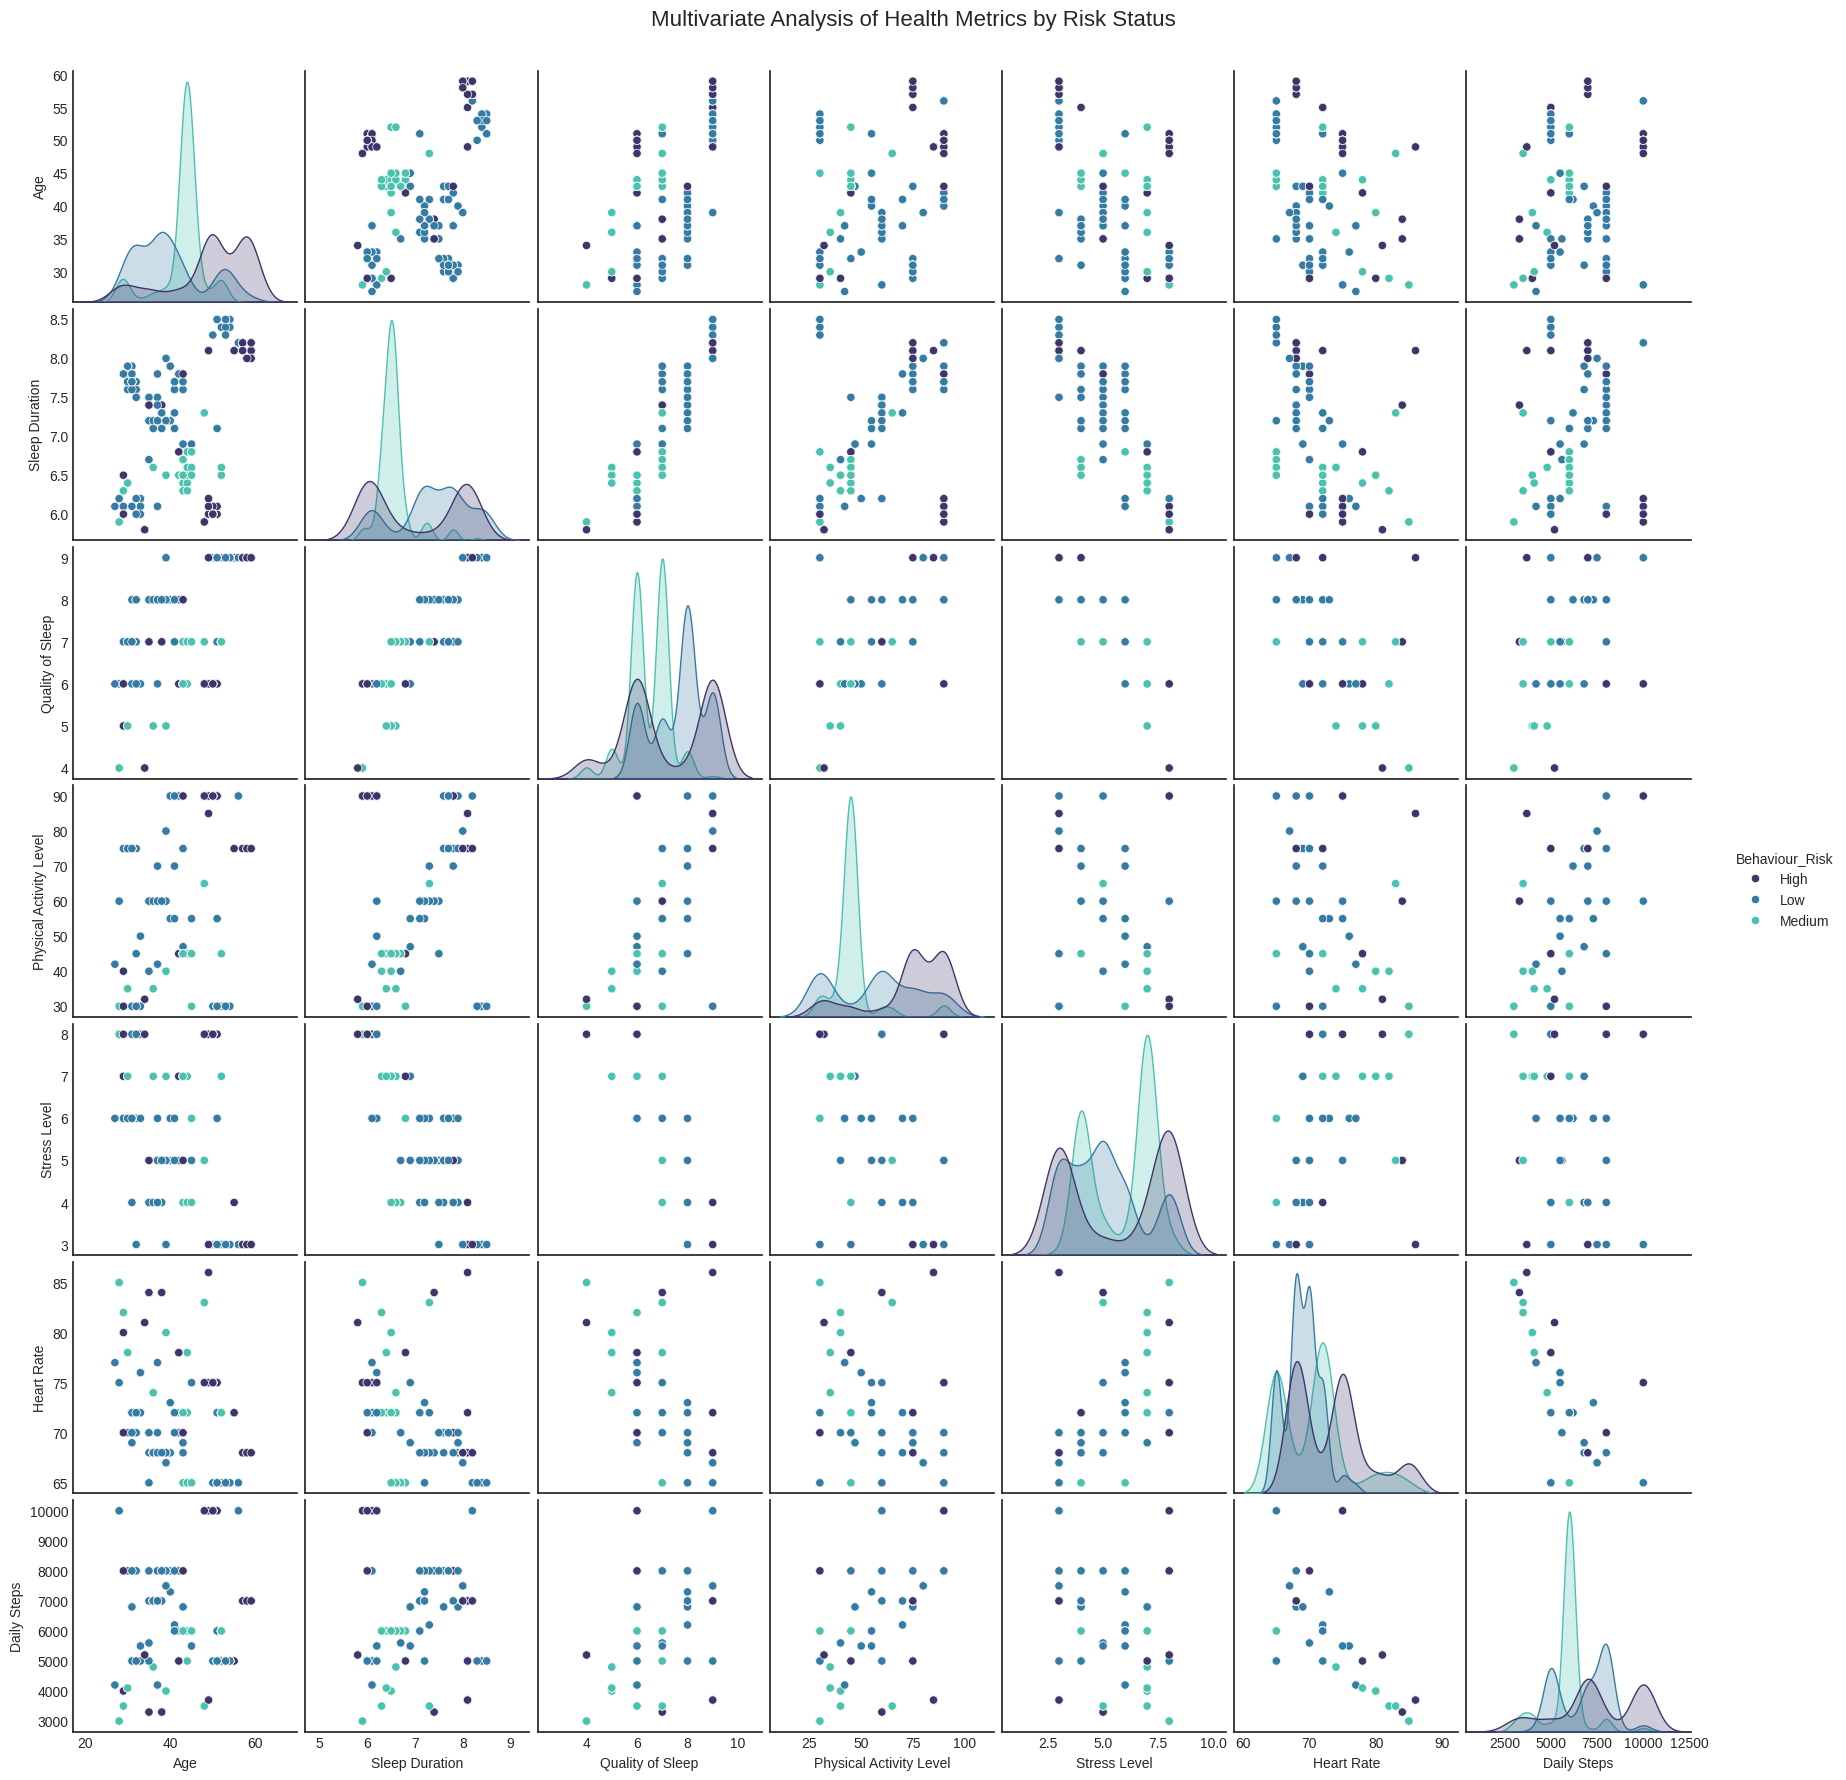

In [ ]:
# ==============================================================================
# PHASE 3: MULTIVARIATE ANALYSIS (PAIR PLOT)
# ==============================================================================

# --- 1. SETTING THE PLOT STYLE ---
# Note: 'seaborn-v0_8-white' is the correct name for newer matplotlib versions
plt.style.use('seaborn-v0_8-white')

# --- 2. GENERATING THE PAIR PLOT ---
# Visualizing pairwise relationships across the entire dataset
# Dropping 'Person ID' as it is a non-predictive unique identifier
# Using 'Behaviour_Risk' for color-coded (hue) classification
sns.pairplot(
    data=df.drop('Person ID', axis=1),
    hue='Behaviour_Risk',
    palette='mako',
    diag_kind='kde' # Adds smooth density plots on the diagonal
)

# --- 3. FINAL RENDERING ---
plt.suptitle("Multivariate Analysis of Health Metrics by Risk Status", y=1.02, fontsize=16)
plt.show()

**Percentage of persons have Behaviour_Risk or not:-**

In [ ]:
classes=colored(df['Behaviour_Risk'].unique(), "magenta",None, attrs=["blink"])
print('The outputs from the classification are :',classes)

The outputs from the classification are : ['High' 'Low' 'Medium']


In [ ]:
df['Behaviour_Risk'].value_counts()

,count
Behaviour_Risk,
High,400
Low,400
Medium,400


In [ ]:
fig=px.histogram(df,x='Behaviour_Risk',
                 barmode="group",color='Behaviour_Risk',
                 color_discrete_sequence=['white','#4A235A','#C39BD3'],
                 text_auto=True)


fig.update_layout(title='<b>Distribution of persons have Behaviour_Risk or not</b>..',
                 title_font={'size':25},
                 paper_bgcolor='#EBDEF0',
                 plot_bgcolor='#EBDEF0',
                 showlegend=True)


fig.update_yaxes(showgrid=False)

fig.show()

In [ ]:
Gender=colored(df['Gender'].unique(), "magenta",None, attrs=["blink"])
print('The values of Sex column are :',Gender)

The values of Sex column are : ['Male' 'Female']


In [ ]:
df.groupby('Behaviour_Risk')['Gender'].value_counts()

Behaviour_Risk  Gender
High            Female    339
                Male       61
Low             Male      237
                Female    163
Medium          Male      211
                Female    189
Name: count, dtype: int64

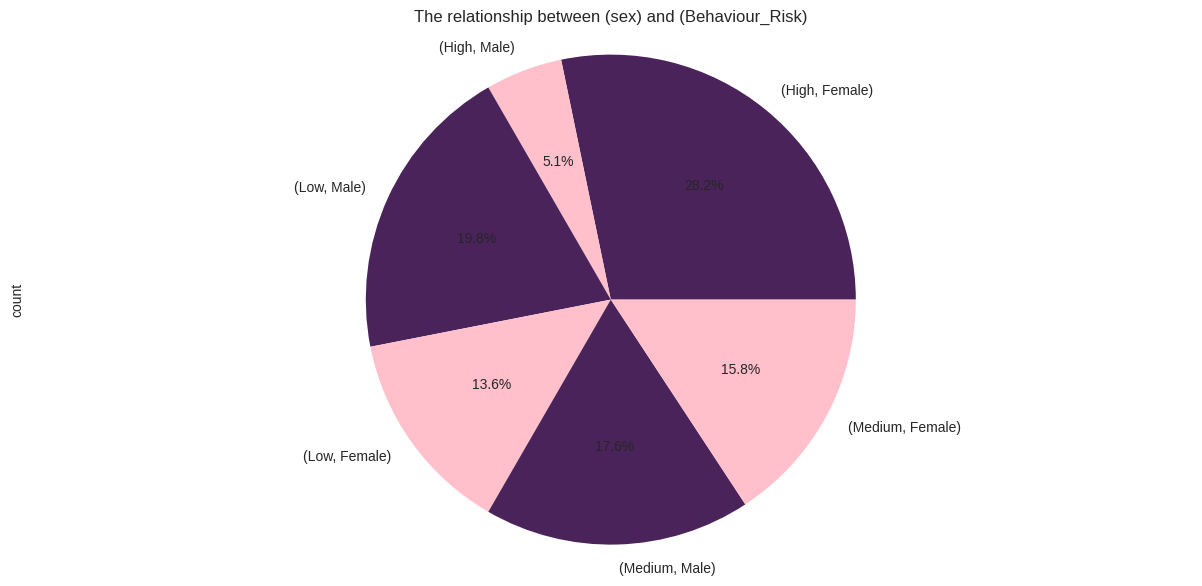

In [ ]:
df.groupby('Behaviour_Risk')['Gender'].value_counts().plot.pie(autopct ='%1.1f%%',figsize=(15,7),
                                                                       colors=['#4A235A','pink','#4A235A','pink','#4A235A','pink'])
plt.title('The relationship between (sex) and (Behaviour_Risk)')
plt.axis('equal')
plt.show()

In [ ]:
jobs=colored(df['Occupation'].unique(), "magenta",None, attrs=["blink"])
print('The types of jobs that exist are :',jobs)

The types of jobs that exist are : ['Sales Representative' 'Nurse' 'Doctor' 'Teacher' 'Lawyer' 'Engineer'
 'Accountant' 'Salesperson' 'Software Engineer' 'Scientist' 'Manager']


In [ ]:
df.groupby('Behaviour_Risk')['Occupation'].value_counts()

Behaviour_Risk  Occupation          
High            Nurse                   308
                Doctor                   20
                Sales Representative     19
                Teacher                  16
                Lawyer                   14
                Scientist                12
                Engineer                  6
                Salesperson               5
Low             Doctor                  114
                Engineer                103
                Lawyer                   81
                Accountant               59
                Nurse                    21
                Teacher                  13
                Scientist                 3
                Software Engineer         3
                Manager                   2
                Salesperson               1
Medium          Teacher                 158
                Salesperson             148
                Accountant               27
                Engineer                 22
                Nurse                    17
                Doctor                   12
                Software Engineer         9
                Lawyer                    7
Name: count, dtype: int64

In [ ]:
fig=px.treemap(df,path=[px.Constant('Jobs'),'Behaviour_Risk','Occupation'],
               color='Behaviour_Risk',
              color_discrete_sequence=['#EBDEF0','#C39BD3','#4A235A'])


fig.update_layout(title='<b>The effect of job on Behaviour_Risk</b>..',
                 title_font={'size':20})


fig.show()

In [ ]:
df.pivot_table(index='Quality of Sleep',columns='Behaviour_Risk',values='Sleep Duration',aggfunc='mean').style.background_gradient(cmap='BuPu')

Behaviour_Risk,High,Low,Medium
Quality of Sleep,,,
4,5.861290,nan,5.900000
5,6.470000,nan,6.500000
6,6.133735,6.135065,6.381928
7,7.485714,7.543333,6.623164
8,7.446154,7.400568,7.500000
9,8.086145,8.332184,8.300000


In [ ]:
fig=px.sunburst(df,path=[px.Constant('Sleep quality'),'Behaviour_Risk','Quality of Sleep'],
               color='Behaviour_Risk',values='Sleep Duration',
              color_discrete_sequence=['pink','#4A235A','#FFF3FD'],
              hover_data=['Gender'])

fig.update_layout(title='<b>The effect of quality of Behaviour_Risk </b>..',
                 title_font={'size':25})

fig.show()

In [ ]:
fig = px.violin(df, x="Behaviour_Risk",y='Physical Activity Level',
                 color='Behaviour_Risk',
                 color_discrete_sequence=['white','#4A235A','#C39BD3'],
                 violinmode='overlay')


fig.update_layout(title='<b>The effect of aBehaviour_Risk </b>..',
                 title_font={'size':25},
                 paper_bgcolor='#EBDEF0',
                 plot_bgcolor='#EBDEF0')

fig.update_yaxes(showgrid=False)
fig.show()

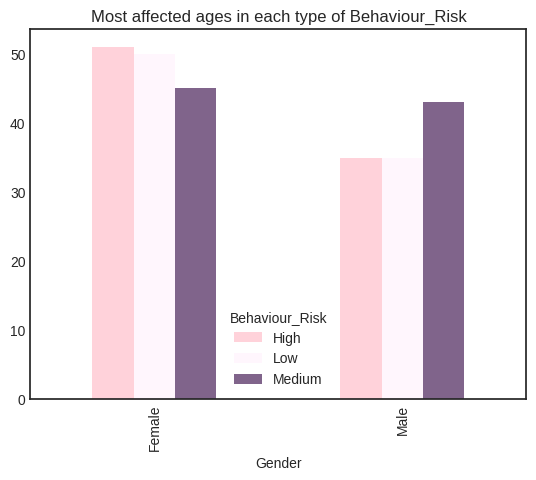

In [ ]:
df.pivot_table(index='Gender',columns='Behaviour_Risk',values='Age',aggfunc='median').plot(kind='bar',color={'#FFF3FD','#4A235A','pink'},
                                                                                                   title='Most affected ages in each type of Behaviour_Risk',
                                                                                                    label='Age',alpha=.7)


plt.show()

In [ ]:
fig=px.ecdf(df,x='Age',
            color='Behaviour_Risk',
            color_discrete_sequence=['white','#4A235A','#C39BD3'])


fig.update_layout(title='<b>The effect of ages on Behaviour_Risk </b>..',
                 title_font={'size':25},
                 paper_bgcolor='#EBDEF0',
                 plot_bgcolor='#EBDEF0')


fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)
fig.show()

In [ ]:
fig=px.histogram(df,x='Behaviour_Risk',y='Sleep Duration',
                 color='Behaviour_Risk',color_discrete_sequence=['white','#4A235A','#C39BD3'],
                 text_auto=True)



fig.update_layout(title='<b>The effect of Sleep Duration on Behaviour_Risk</b> ..',
                  titlefont={'size': 24,'family': 'Serif'},
                  showlegend=True,
                  paper_bgcolor='#EBDEF0',
                  plot_bgcolor='#EBDEF0')



fig.update_yaxes(showgrid=False)




fig.show()

In [ ]:
fig=px.scatter_3d(df,x='BMI Category',y='Blood Pressure',z='Heart Rate',
                  color='Behaviour_Risk',width=1000,height=900,
                  color_discrete_sequence=['white','#4A235A','#C39BD3'])


fig.update_layout(title='<b>The relationship between (BMI Category , Blood Pressure and Heart Rate) and their effect on  Behaviour_Risk</b> ..',
                  titlefont={'size': 20,'family': 'Serif'},
                  showlegend=True)



fig.show()

In [ ]:
df.pivot_table(index='Stress Level',columns='Behaviour_Risk',aggfunc={'Behaviour_Risk':'count'}).style.background_gradient(cmap='BuPu')

In [ ]:
fig=px.histogram(df,x='Behaviour_Risk',
                 color='Behaviour_Risk',
                 facet_col='Stress Level',
                 barmode='group',
                 color_discrete_sequence=['white','#4A235A','#C39BD3'],
                 opacity=.8)


fig.update_layout(title='<b>The effect of Stress Level on Behaviour_Risk</b> ..',title_font={'size':30},
                  paper_bgcolor='#EBDEF0',
                  plot_bgcolor='#EBDEF0')



fig.update_yaxes(showgrid=False)
fig.show()

In [ ]:
BMI_Category=colored(df['BMI Category'].unique(), "magenta",None, attrs=["blink"])
print('The values of BMI Category column are :',BMI_Category)

The values of BMI Category column are : ['Obese' 'Overweight' 'Healthy Weight']


In [ ]:
df.pivot_table(index='BMI Category',columns='Behaviour_Risk',aggfunc={'Behaviour_Risk':'count'}).style.background_gradient(cmap='BuPu')

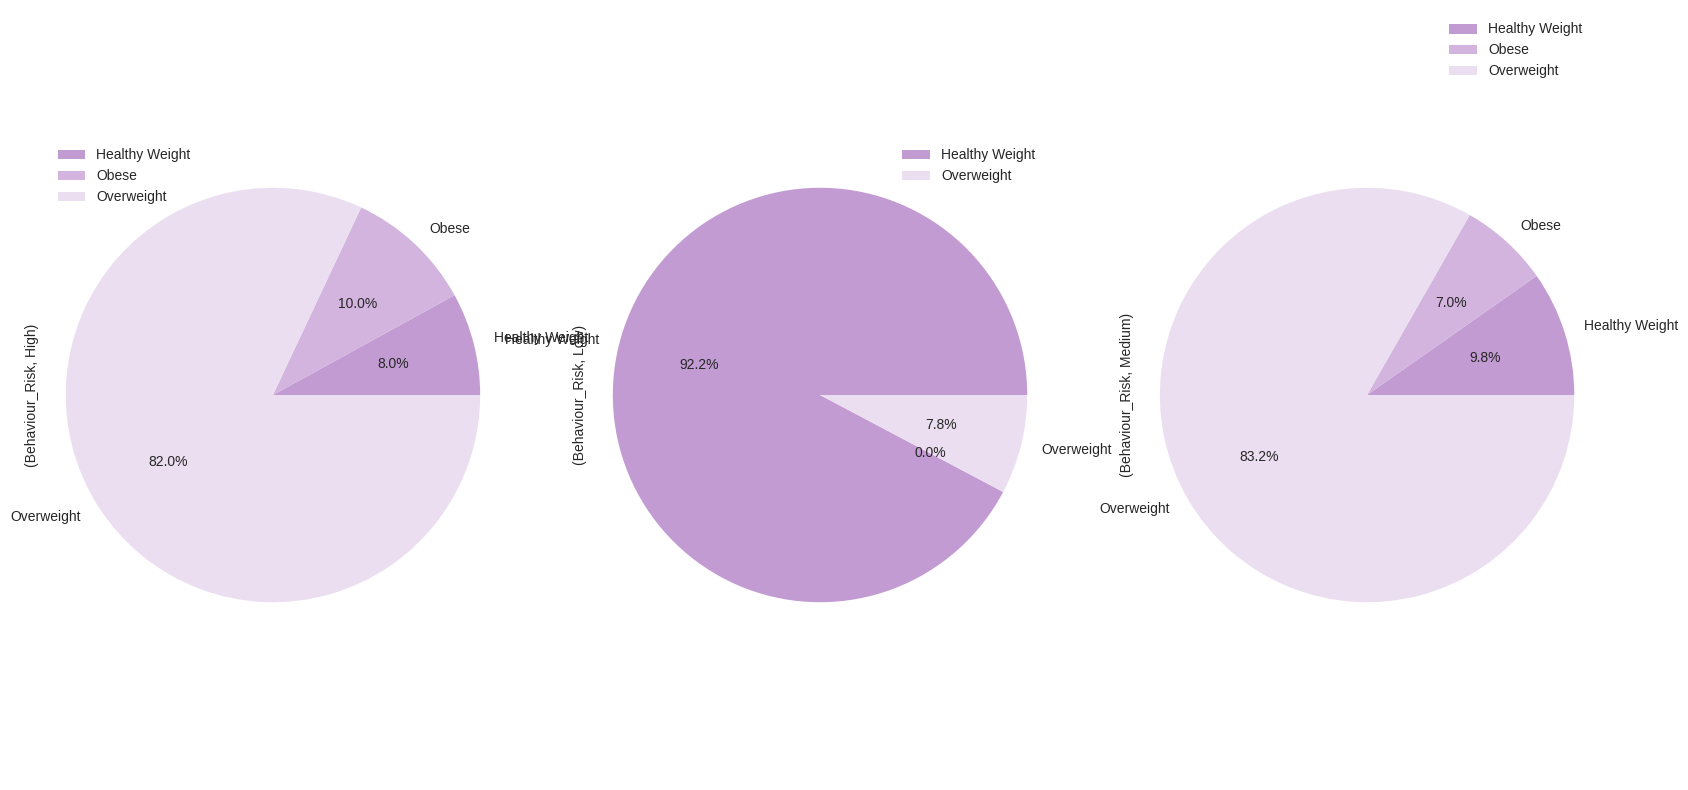

In [ ]:
df.pivot_table(index='BMI Category',columns='Behaviour_Risk',aggfunc={'Behaviour_Risk':'count'}).plot.pie(autopct ='%1.1f%%',
                                                                                                                  subplots=True,figsize=(20,10),
                                                                                                                  colors=['#C39BD3','#D2B4DE','#EBDEF0','#F4ECF7'])

plt.axis('equal')
plt.show()

# **Data preprocessing 🛠️**

In [ ]:
df.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Behaviour_Risk'],
      dtype='object')

In [ ]:
# feature engineering
df.drop('Person ID', axis=1, inplace=True)

In [ ]:
df.isna().sum()


,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0
Heart Rate,0


<Axes: >

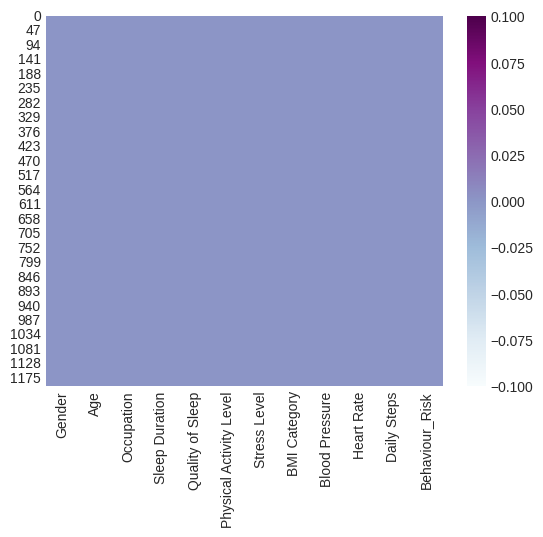

In [ ]:
sns.heatmap(df.isna(),cmap='BuPu')


In [ ]:
print(df['Behaviour_Risk'].unique())
print("Labels and Counts:")
print(df['Behaviour_Risk'].value_counts())

['High' 'Low' 'Medium']
Labels and Counts:
Behaviour_Risk
High      400
Low       400
Medium    400
Name: count, dtype: int64


In [ ]:
# Normal / Healthy Weight: BMI 18.5 to 24.9. (Total count: 195 + 21 = 216) — This indicates a healthy body weight.
# Overweight: BMI 25 to 29.9. (Total count: $148$) — This indicates that the body weight is slightly high.
# Obese: BMI 30 or above. (Total count: $10$) — This indicates excessive body fat (obesity).

print(df['BMI Category'].unique())
print(df['BMI Category'].value_counts())

['Obese' 'Overweight' 'Healthy Weight']
BMI Category
Overweight        692
Healthy Weight    440
Obese              68
Name: count, dtype: int64


In [ ]:
df['Occupation'].unique()
print(df['Occupation'].value_counts())

Occupation
Nurse                   346
Teacher                 187
Salesperson             154
Doctor                  146
Engineer                131
Lawyer                  102
Accountant               86
Sales Representative     19
Scientist                15
Software Engineer        12
Manager                   2
Name: count, dtype: int64


In [ ]:
df['Occupation'] = df['Occupation'].replace('Sales Representative', 'Sales_person')
df['Occupation'] = df['Occupation'].replace('Salesperson', 'Student')
print(df['Occupation'].value_counts())

Occupation
Nurse                346
Teacher              187
Student              154
Doctor               146
Engineer             131
Lawyer               102
Accountant            86
Sales_person          19
Scientist             15
Software Engineer     12
Manager                2
Name: count, dtype: int64


In [ ]:
print("\n--- Whitespace Check in String Columns ---")
object_cols = df.select_dtypes(include=['object']).columns
for col in object_cols:
    whitespace_count = df[col].dropna().astype(str).str.contains(r'^\s|\s$').sum()
    if whitespace_count > 0:
            print(f"Column '{col}': Found {whitespace_count} rows with leading/trailing spaces.")
    else:
            print(f"Column '{col}': No leading/trailing spaces found.")


--- Whitespace Check in String Columns ---
Column 'Gender': No leading/trailing spaces found.
Column 'Occupation': No leading/trailing spaces found.
Column 'BMI Category': No leading/trailing spaces found.
Column 'Blood Pressure': No leading/trailing spaces found.
Column 'Behaviour_Risk': No leading/trailing spaces found.


In [ ]:
# Removes unnecessary spaces from string columns
object_cols = df.select_dtypes(include=['object']).columns
for col in object_cols:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df['Blood Pressure'].unique()

array(['140/90', '140/95', '120/80', '135/90', '126/83', '130/85',
       '125/80', '115/75', '130/86', '132/87', '117/76', '125/82',
       '121/79', '139/91', '131/86', '135/88', '118/75', '142/92',
       '115/78', '122/80', '128/85', '129/84', '128/84', '119/77'],
      dtype=object)

In [ ]:
df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True)
df['Systolic'] = pd.to_numeric(df['Systolic'])
df['Diastolic'] = pd.to_numeric(df['Diastolic'])
df.drop('Blood Pressure', axis=1, inplace=True)

In [ ]:
print(df[['Systolic', 'Diastolic']].head())

   Systolic  Diastolic
0       140         90
1       140         95
2       120         80
3       135         90
4       126         83


In [ ]:
# 1. Get a list of all existing column names
cols = list(df.columns)

# 2. Temporarily remove the 'Behaviour_Risk' column from the list
cols.remove('Behaviour_Risk')

# 3. Append 'Behaviour_Risk' to the end of the remaining list
cols.append('Behaviour_Risk')

# 4. Reorder the dataframe using this new column sequence
df = df[cols]

# Now, when printed, 'Behaviour_Risk' will be the last column
print("Updated Columns:", df.columns.tolist())
df.head()

Updated Columns: ['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Heart Rate', 'Daily Steps', 'Systolic', 'Diastolic', 'Behaviour_Risk']


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Systolic,Diastolic,Behaviour_Risk
0,Male,28,Sales_person,5.9,4,30,8,Obese,85,3000,140,90,High
1,Female,50,Nurse,6.0,6,90,8,Overweight,75,10000,140,95,High
2,Male,31,Doctor,7.7,7,75,6,Healthy Weight,70,8000,120,80,Low
3,Female,44,Teacher,6.6,7,45,4,Overweight,65,6000,135,90,Medium
4,Female,37,Nurse,6.1,6,42,6,Overweight,77,4200,126,83,Low


In [ ]:
df.to_csv('Preprocessed_Dataset.csv', index=False)

In [ ]:
#for converting non-numeric data (String or Boolean) into numbers
le_gender = LabelEncoder()
le_occ = LabelEncoder()
le_bmi = LabelEncoder()
le_target = LabelEncoder()

df['Gender'] = le_gender.fit_transform(df['Gender'])
df['Occupation'] = le_occ.fit_transform(df['Occupation'])
df['BMI Category'] = le_bmi.fit_transform(df['BMI Category'])
df['Behaviour_Risk'] = le_target.fit_transform(df['Behaviour_Risk'])

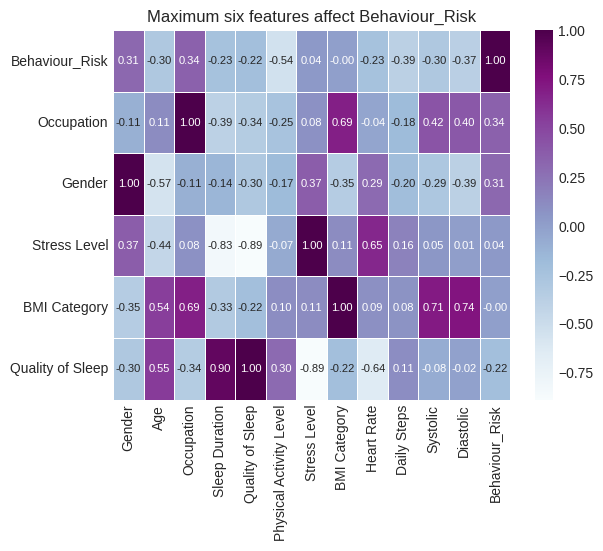

In [ ]:
correlation=df.corr()
max_6_corr=correlation.nlargest(6,"Behaviour_Risk")
sns.heatmap(max_6_corr,annot=True,fmt=".2F",annot_kws={"size":8},linewidths=0.5,cmap='BuPu')
plt.title('Maximum six features affect Behaviour_Risk')
plt.show()

# **Data Spliting**

In [ ]:
X = df.drop('Behaviour_Risk', axis=1)
y = df['Behaviour_Risk']


print('The dimensions of x is : ',X.shape)
print('The dimensions of y is : ',y.shape)

The dimensions of x is :  (1200, 12)
The dimensions of y is :  (1200,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("x train dimensions :",X_train.shape)
print("x test dimensions: ",X_test.shape)
print("y train dimensions :",y_train.shape)
print("y test dimensions :",y_test.shape)

x train dimensions : (960, 12)
x test dimensions:  (240, 12)
y train dimensions : (960,)
y test dimensions : (240,)


# **Data modeling**

**LogisticRegression Model:-**

LR Training Accuracy : 87.4%
LR Testing Accuracy  : 87.92%

📊 Classification Report (Logistic Regression)

              precision    recall  f1-score   support

           0       0.89      0.88      0.89        94
           1       0.89      0.93      0.91        75
           2       0.85      0.82      0.83        71

    accuracy                           0.88       240
   macro avg       0.88      0.88      0.88       240
weighted avg       0.88      0.88      0.88       240



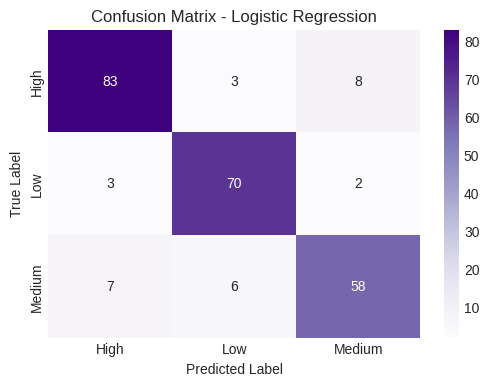

In [ ]:
# -------------------------------
# 1. Train Logistic Regression
# -------------------------------
# max_iter=1000 ensures the model has enough iterations to converge/find the best fit
lr_model = LogisticRegression(max_iter=2000, C=1.0, solver='liblinear')
lr_model.fit(X_train, y_train)

# ------------------------------
# 2. Accuracy Scores with Colors
# -------------------------------
# Calculate Training Accuracy
lr_training_score = colored(
    round(lr_model.score(X_train, y_train) * 100, 2),
    "magenta", attrs=["bold"]
)

# Calculate Testing Accuracy
lr_testing_score = colored(
    round(lr_model.score(X_test, y_test) * 100, 2),
    "magenta", attrs=["bold"]
)

print(f"LR Training Accuracy : {lr_training_score}%")
print(f"LR Testing Accuracy  : {lr_testing_score}%")

# -------------------------------
# 3. Predictions
# -------------------------------
# Use the trained model to predict outcomes for the test dataset
y_pred_lr = lr_model.predict(X_test)

# -------------------------------
# 4. Classification Report
# -------------------------------
# Provides details on Precision, Recall, and F1-score for each class
print("\n📊 Classification Report (Logistic Regression)\n")
print(classification_report(y_test, y_pred_lr))

# -------------------------------
# 5. Confusion Matrix (Visualization)
# -------------------------------
# This matrix shows exactly where the model is making correct predictions and where it is failing
cm = confusion_matrix(y_test, y_pred_lr)



plt.figure(figsize=(6, 4))
# Heatmap visualization with actual labels (Low, Medium, High)
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

**GradientBoostingClassifier Model:-**

GB Training Accuracy : 93.23%
GB Testing Accuracy  : 94.17%

📊 Classification Report (Gradient Boosting)

              precision    recall  f1-score   support

           0       0.95      0.97      0.96        94
           1       0.91      0.96      0.94        75
           2       0.97      0.89      0.93        71

    accuracy                           0.94       240
   macro avg       0.94      0.94      0.94       240
weighted avg       0.94      0.94      0.94       240



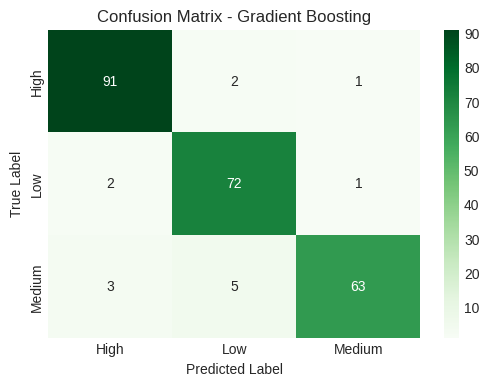

In [ ]:
# -------------------------------
# 1. Train Gradient Boosting Classifier
# -------------------------------
# n_estimators: Number of boosting stages to perform
# learning_rate: Shrinks the contribution of each tree to prevent overfitting
# max_depth: Limits the number of nodes in the tree
gb_model = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
gb_model.fit(X_train, y_train)

# ------------------------------
# 2. Accuracy Scores with Colors
# -------------------------------
# Calculate Training Accuracy
gb_training_score = colored(
    round(gb_model.score(X_train, y_train) * 100, 2),
    "green", attrs=["bold"]
)

# Calculate Testing Accuracy
gb_testing_score = colored(
    round(gb_model.score(X_test, y_test) * 100, 2),
    "green", attrs=["bold"]
)

print(f"GB Training Accuracy : {gb_training_score}%")
print(f"GB Testing Accuracy  : {gb_testing_score}%")

# -------------------------------
# 3. Predictions
# -------------------------------
# Predicting labels for the test set
y_pred_gb = gb_model.predict(X_test)

# -------------------------------
# 4. Classification Report
# -------------------------------
# Detailed breakdown of precision, recall, and f1-score for High, Medium, and Low risk
print("\n📊 Classification Report (Gradient Boosting)\n")
print(classification_report(y_test, y_pred_gb))

# -------------------------------
# 5. Confusion Matrix (Visualization)
# -------------------------------
# Visualizing the accuracy of predictions across different classes
cm_gb = confusion_matrix(y_test, y_pred_gb)



plt.figure(figsize=(6, 4))
# Using "Greens" colormap to distinguish it from Logistic Regression
sns.heatmap(cm_gb, annot=True, fmt="d", cmap="Greens",
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

**XGBClassifier Model:-**

XGB Training Accuracy : 93.23%
XGB Testing Accuracy  : 94.17%

📊 Classification Report (XGBoost)

              precision    recall  f1-score   support

           0       0.95      0.97      0.96        94
           1       0.91      0.96      0.94        75
           2       0.97      0.89      0.93        71

    accuracy                           0.94       240
   macro avg       0.94      0.94      0.94       240
weighted avg       0.94      0.94      0.94       240



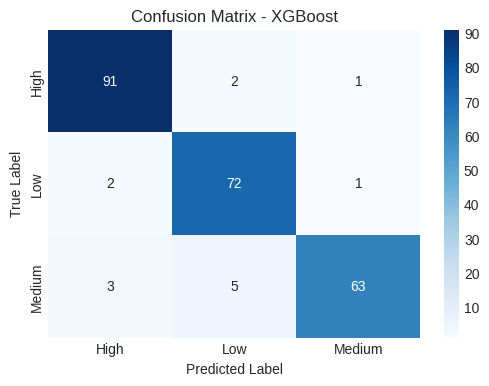

In [ ]:
# -------------------------------
# 1. Train XGBoost Classifier
# -------------------------------
# n_estimators: Number of boosting trees to fit
# learning_rate: Step size shrinkage used in update to prevent overfitting
# max_depth: Maximum tree depth for base learners
xgb_model = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)

# ------------------------------
# 2. Accuracy Scores with Colors
# -------------------------------
# Calculate Training Accuracy
xgb_training_score = colored(
    round(xgb_model.score(X_train, y_train) * 100, 2),
    "cyan", attrs=["bold"]
)

# Calculate Testing Accuracy
xgb_testing_score = colored(
    round(xgb_model.score(X_test, y_test) * 100, 2),
    "cyan", attrs=["bold"]
)

print(f"XGB Training Accuracy : {xgb_training_score}%")
print(f"XGB Testing Accuracy  : {xgb_testing_score}%")

# -------------------------------
# 3. Predictions
# -------------------------------
# Performing predictions on the test dataset
y_pred_xgb = xgb_model.predict(X_test)

# -------------------------------
# 4. Classification Report
# -------------------------------
# Comprehensive report showing Precision, Recall, and F1-score
print("\n📊 Classification Report (XGBoost)\n")
print(classification_report(y_test, y_pred_xgb))

# -------------------------------
# 5. Confusion Matrix (Visualization)
# -------------------------------
# Analyzing the distribution of correct and incorrect predictions
cm_xgb = confusion_matrix(y_test, y_pred_xgb)



plt.figure(figsize=(6, 4))
# Using "Blues" colormap for XGBoost visualization
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues",
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

**Random Forest Classifier:-**

RF Training Accuracy : 93.23%
RF Testing Accuracy  : 93.33%

📊 Classification Report (Random Forest)

              precision    recall  f1-score   support

           0       0.93      0.97      0.95        94
           1       0.91      0.93      0.92        75
           2       0.97      0.89      0.93        71

    accuracy                           0.93       240
   macro avg       0.94      0.93      0.93       240
weighted avg       0.93      0.93      0.93       240



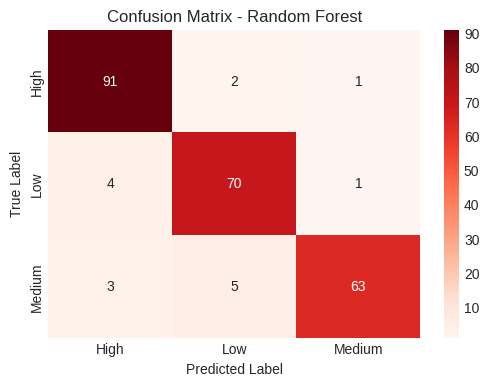

In [ ]:
# -------------------------------
# 1. Train Random Forest Classifier
# -------------------------------
# n_estimators: The number of trees in the forest
# max_depth: The maximum depth of each tree to control overfitting
# random_state: Ensures the results are reproducible
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# ------------------------------
# 2. Accuracy Scores with Colors
# -------------------------------
# Calculate Training Accuracy
rf_training_score = colored(
    round(rf_model.score(X_train, y_train) * 100, 2),
    "red", attrs=["bold"]
)

# Calculate Testing Accuracy
rf_testing_score = colored(
    round(rf_model.score(X_test, y_test) * 100, 2),
    "red", attrs=["bold"]
)

print(f"RF Training Accuracy : {rf_training_score}%")
print(f"RF Testing Accuracy  : {rf_testing_score}%")

# -------------------------------
# 3. Predictions
# -------------------------------
# Generating predictions using the test feature set
y_pred_rf = rf_model.predict(X_test)

# -------------------------------
# 4. Classification Report
# -------------------------------
# Detailed metrics (Precision, Recall, F1-Score) for each risk category
print("\n📊 Classification Report (Random Forest)\n")
print(classification_report(y_test, y_pred_rf))

# -------------------------------
# 5. Confusion Matrix (Visualization)
# -------------------------------
# Visual representation of predicted vs actual results
cm_rf = confusion_matrix(y_test, y_pred_rf)



plt.figure(figsize=(6, 4))
# Using "Reds" colormap for the Random Forest visualization
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Reds",
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

**CatBoostClassifier Model:-**

In [ ]:
# # -------------------------------
# # 1. Train CatBoost Classifier
# # -------------------------------
# # verbose=False: Prevents the model from printing training logs for every iteration
# cbc_model = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6, verbose=False, random_state=42)
# cbc_model.fit(X_train, y_train)

# # -------------------------------
# # 2. Accuracy Scores with Colors
# # -------------------------------
# # Calculate Training Accuracy
# cbc_training_score = colored(
#     round(cbc_model.score(X_train, y_train) * 100, 2),
#     "magenta", attrs=["bold"]
# )

# # Calculate Testing Accuracy
# cbc_testing_score = colored(
#     round(cbc_model.score(X_test, y_test) * 100, 2),
#     "magenta", attrs=["bold"]
# )

# print(f"CBC Training Score : {cbc_training_score}%")
# print(f"CBC Testing Score  : {cbc_testing_score}%")

# # -------------------------------
# # 3. Predictions
# # -------------------------------
# # Generating predictions for the test dataset
# y_pred_cbc = cbc_model.predict(X_test)

# # -------------------------------
# # 4. Classification Report
# # -------------------------------
# # Displays Precision, Recall, and F1-score for each Behaviour_Risk risk level
# print("\n📊 Classification Report (CatBoost)\n")
# print(classification_report(y_test, y_pred_cbc))

# # -------------------------------
# # 5. Confusion Matrix (Visualization)
# # -------------------------------
# # Visualizing how many samples were correctly categorized
# cm_cbc = confusion_matrix(y_test, y_pred_cbc)



# plt.figure(figsize=(6, 4))
# # Using "YlGnBu" (Yellow-Green-Blue) colormap to make this stand out as your high-accuracy model
# sns.heatmap(cm_cbc, annot=True, fmt="d", cmap="YlGnBu",
#             xticklabels=le_target.classes_,
#             yticklabels=le_target.classes_)
# plt.title("Confusion Matrix - CatBoost")
# plt.xlabel("Predicted Label")
# plt.ylabel("True Label")
# plt.show()

# **Models evaluation 📝**

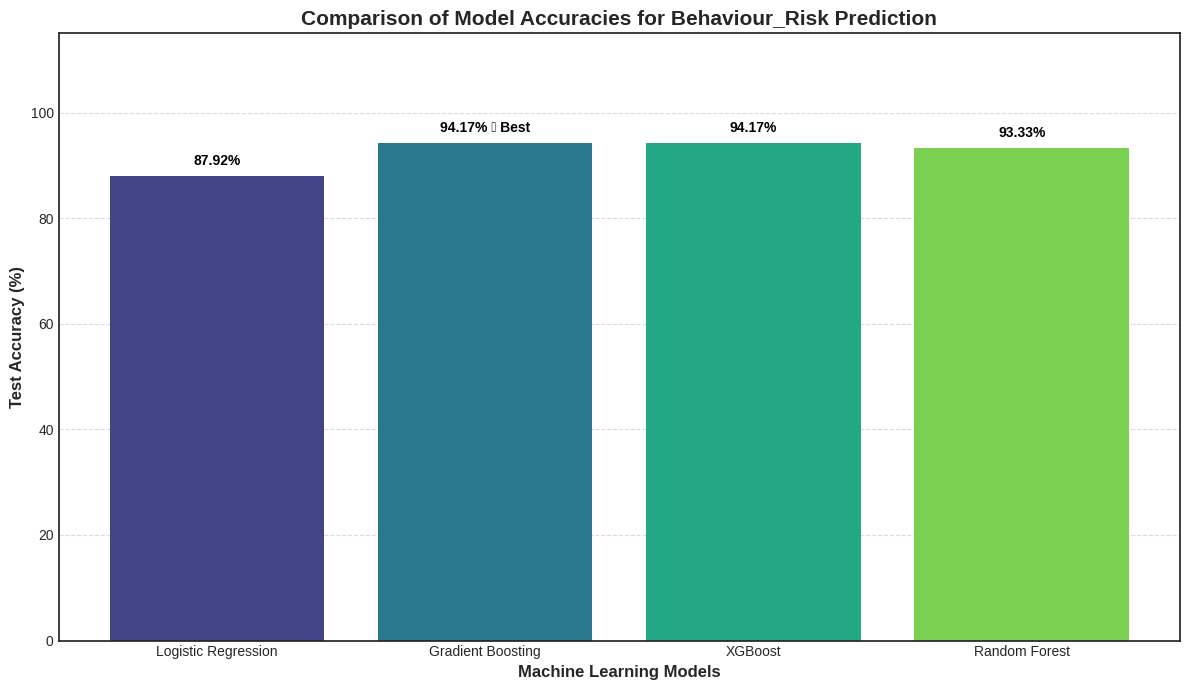

In [ ]:
# 1. Prepare the data
models = [
    "Logistic Regression",
    "Gradient Boosting",
    "XGBoost",
    # "CatBoost",
    "Random Forest"
]

# Collecting scores from the models
test_accuracies = [
    lr_model.score(X_test, y_test) * 100,
    gb_model.score(X_test, y_test) * 100,
    xgb_model.score(X_test, y_test) * 100,
    # cbc_model.score(X_test, y_test) * 100,
    rf_model.score(X_test, y_test) * 100
]

# --- FIX: Automatically find the index of the best model ---
best_index = np.argmax(test_accuracies)

# 2. Create the visualization
plt.figure(figsize=(12, 7))
colors = sns.color_palette("viridis", len(models))

# Create bar plot
bars = plt.bar(models, test_accuracies, color=colors)

# 3. Add details to the plot
plt.xlabel("Machine Learning Models", fontsize=12, fontweight='bold')
plt.ylabel("Test Accuracy (%)", fontsize=12, fontweight='bold')
plt.title("Comparison of Model Accuracies for Behaviour_Risk Prediction", fontsize=15, fontweight='bold')
plt.ylim(0, 115) # Increased limit slightly for the "Best" label
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Accuracy values on top of bars (Cleaned up loop)
for i, bar in enumerate(bars):
    yval = bar.get_height()
    label = f"{round(yval, 2)}%"

    # Add Star to the highest bar
    if i == best_index:
        label += " ⭐ Best"

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 1.5, # Positioned slightly above the bar
        label,
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="black"
    )

# Show plot once
plt.tight_layout()
plt.show()

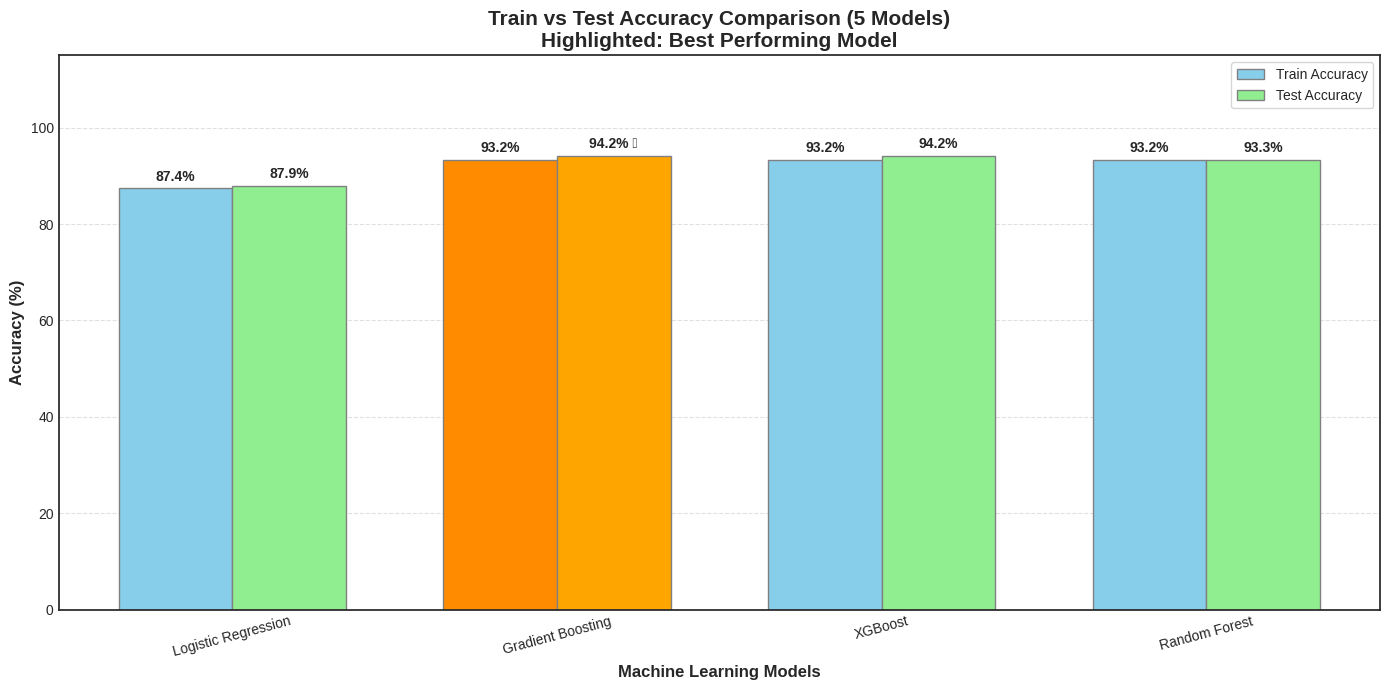

--------------------------------------------------
🏆 Best Model (by Test Accuracy): Gradient Boosting
✅ Highest Test Accuracy: 94.17 %
📊 Training Accuracy for same model: 93.23 %
--------------------------------------------------


In [ ]:
# 1. Setup Models and Accuracy Data
models = [
    "Logistic Regression",
    "Gradient Boosting",
    "XGBoost",
    # "CatBoost",
    "Random Forest"
]

# Using the specific model variables we trained earlier
# (Make sure these variables match exactly what you used in previous cells)
train_accuracies = [
    lr_model.score(X_train, y_train) * 100,
    gb_model.score(X_train, y_train) * 100,
    xgb_model.score(X_train, y_train) * 100,
    # cbc_model.score(X_train, y_train) * 100,
    rf_model.score(X_train, y_train) * 100
]

test_accuracies = [
    lr_model.score(X_test, y_test) * 100,
    gb_model.score(X_test, y_test) * 100,
    xgb_model.score(X_test, y_test) * 100,
    # cbc_model.score(X_test, y_test) * 100,
    rf_model.score(X_test, y_test) * 100
]

# Find the index of the best model based on Test Accuracy
best_index = test_accuracies.index(max(test_accuracies))

# 2. Setup Bar Plot Configuration
x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(14, 7))

# Define color schemes
train_colors = ["#87CEEB"] * len(models)
test_colors  = ["#90EE90"] * len(models)

# Highlighting the Best Model in Orange
train_colors[best_index] = "#FF8C00"
test_colors[best_index]  = "#FFA500"

# 3. Create Grouped Bar Charts
bars1 = plt.bar(x - width/2, train_accuracies, width, label="Train Accuracy", color=train_colors, edgecolor='grey')
bars2 = plt.bar(x + width/2, test_accuracies,  width, label="Test Accuracy",  color=test_colors, edgecolor='grey')

# 4. Styling the Chart
plt.xlabel("Machine Learning Models", fontweight='bold', fontsize=12)
plt.ylabel("Accuracy (%)", fontweight='bold', fontsize=12)
plt.title("Train vs Test Accuracy Comparison (5 Models)\nHighlighted: Best Performing Model", fontsize=15, fontweight='bold')
plt.xticks(x, models, rotation=15)
plt.ylim(0, 115)
plt.grid(axis="y", linestyle='--', alpha=0.6)
plt.legend(loc='upper right', frameon=True)

# 5. Adding Data Labels on top of bars
def add_labels(bars, is_test_bar=False):
    for i, bar in enumerate(bars):
        yval = bar.get_height()
        label_text = f"{round(yval, 1)}%"

        if is_test_bar and i == best_index:
            label_text += " 🏆"

        plt.text(
            bar.get_x() + bar.get_width()/2,
            yval + 1,
            label_text,
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

add_labels(bars1)
add_labels(bars2, is_test_bar=True)

plt.tight_layout()
plt.show()

# 6. Print Summary Statistics
print("-" * 50)
print(f"🏆 Best Model (by Test Accuracy): {models[best_index]}")
print(f"✅ Highest Test Accuracy: {round(max(test_accuracies), 2)} %")
print(f"📊 Training Accuracy for same model: {round(train_accuracies[best_index], 2)} %")
print("-" * 50)

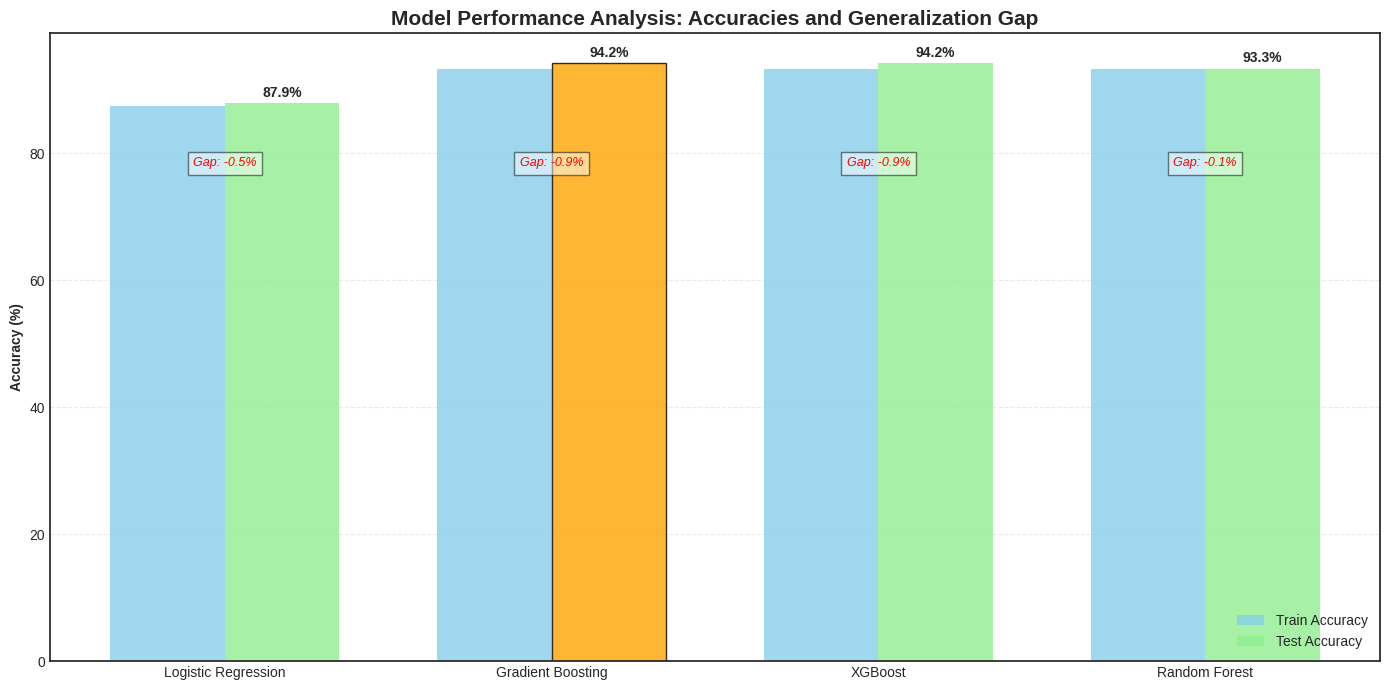

The best model is Gradient Boosting with a gap of only -0.94%.


In [ ]:
# 1. Setup Models and Accuracy Data
models = [
    "Logistic Regression",
    "Gradient Boosting",
    "XGBoost",
    # "CatBoost",
    "Random Forest"
]

# Using the specific model variables we trained earlier
# (Make sure these variables match exactly what you used in previous cells)
train_accuracies = [
    lr_model.score(X_train, y_train) * 100,
    gb_model.score(X_train, y_train) * 100,
    xgb_model.score(X_train, y_train) * 100,
    # cbc_model.score(X_train, y_train) * 100,
    rf_model.score(X_train, y_train) * 100
]

test_accuracies = [
    lr_model.score(X_test, y_test) * 100,
    gb_model.score(X_test, y_test) * 100,
    xgb_model.score(X_test, y_test) * 100,
    # cbc_model.score(X_test, y_test) * 100,
    rf_model.score(X_test, y_test) * 100
]

# Calculating the Generalization Gap (Lower is better)
gaps = [train - test for train, test in zip(train_accuracies, test_accuracies)]
best_index = test_accuracies.index(max(test_accuracies))

# 2. Plotting
x = np.arange(len(models))
width = 0.35
plt.figure(figsize=(14, 7))

# Accuracies Plot
bars1 = plt.bar(x - width/2, train_accuracies, width, label="Train Accuracy", color='#87CEEB', alpha=0.8)
bars2 = plt.bar(x + width/2, test_accuracies, width, label="Test Accuracy", color='#90EE90', alpha=0.8)

# Highlighting the Best Model
bars2[best_index].set_color('#FFA500')
bars2[best_index].set_edgecolor('black')

# 3. Styling
plt.ylabel("Accuracy (%)", fontweight='bold')
plt.title("Model Performance Analysis: Accuracies and Generalization Gap", fontsize=15, fontweight='bold')
plt.xticks(x, models)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.4)

# 4. Adding labels and the Gap info
for i in range(len(models)):
    # Add Test Accuracy labels
    plt.text(x[i] + width/2, test_accuracies[i] + 1, f"{test_accuracies[i]:.1f}%", ha='center', fontweight='bold')

    # Add Overfitting Gap info (in red text)
    plt.text(x[i], min(test_accuracies) - 10, f"Gap: {gaps[i]:.1f}%",
             ha='center', color='red', fontsize=9, style='italic', bbox=dict(facecolor='white', alpha=0.5))



plt.tight_layout()
plt.show()

print(f"The best model is {models[best_index]} with a gap of only {gaps[best_index]:.2f}%.")

In [ ]:
# 1. Setup Models and Accuracy Data
models = [
    "Logistic Regression",
    "Gradient Boosting",
    "XGBoost",
    # "CatBoost",
    "Random Forest"
]

# 2. Convert accuracies to NumPy arrays to allow mathematical operations
train_accuracies = np.array([
    lr_model.score(X_train, y_train) * 100,
    gb_model.score(X_train, y_train) * 100,
    xgb_model.score(X_train, y_train) * 100,
    # cbc_model.score(X_train, y_train) * 100,
    rf_model.score(X_train, y_train) * 100
])

test_accuracies = np.array([
    lr_model.score(X_test, y_test) * 100,
    gb_model.score(X_test, y_test) * 100,
    xgb_model.score(X_test, y_test) * 100,
    # cbc_model.score(X_test, y_test) * 100,
    rf_model.score(X_test, y_test) * 100
])

# 3. Calculate Gap (Train - Test) and Final Score
gaps = train_accuracies - test_accuracies

# Balanced score: Higher accuracy and lower gap is better
final_scores = test_accuracies - gaps

# 4. Find Indices
best_acc_idx = np.argmax(test_accuracies)
stable_idx = np.argmin(gaps)
final_idx = np.argmax(final_scores)

# 5. Professional Output
print(f"🏆 Best Overall Model: {models[final_idx]}")
print(f"✅ Highest Accuracy: {round(test_accuracies[best_acc_idx], 2)} %")
print("-" * 50)

print("📊 ANALYSIS SUMMARY:")

print(f"\n1. Best Accuracy Model:")
print(f"   🚀 {models[best_acc_idx]} | Test Acc = {test_accuracies[best_acc_idx]:.2f}%")

print(f"\n2. Most Stable Model (Lowest Overfitting):")
print(f"   🛡️ {models[stable_idx]} | Gap = {gaps[stable_idx]:.2f}% (Train {train_accuracies[stable_idx]:.2f}% / Test {test_accuracies[stable_idx]:.2f}%)")

print(f"\n3. Final Recommended Model (Accuracy + Stability Balance):")
print(f"   ⭐ {models[final_idx]} | Balance Score = {final_scores[final_idx]:.2f}")
print(f"      (Test {test_accuracies[final_idx]:.2f}% | Gap {gaps[final_idx]:.2f}%)")
print("-" * 50)

🏆 Best Overall Model: Gradient Boosting
✅ Highest Accuracy: 94.17 %
--------------------------------------------------
📊 ANALYSIS SUMMARY:

1. Best Accuracy Model:
   🚀 Gradient Boosting | Test Acc = 94.17%

2. Most Stable Model (Lowest Overfitting):
   🛡️ Gradient Boosting | Gap = -0.94% (Train 93.23% / Test 94.17%)

3. Final Recommended Model (Accuracy + Stability Balance):
   ⭐ Gradient Boosting | Balance Score = 95.10
      (Test 94.17% | Gap -0.94%)
--------------------------------------------------


In [ ]:
# 1. Setup Models and Accuracy Data
models = [
    "Logistic Regression",
    "Gradient Boosting",
    "XGBoost",
    # "CatBoost",
    "Random Forest"
]

# Convert lists to NumPy arrays for mathematical operations
train_acc = np.array([
    lr_model.score(X_train, y_train) * 100,
    gb_model.score(X_train, y_train) * 100,
    xgb_model.score(X_train, y_train) * 100,
    # cbc_model.score(X_train, y_train) * 100,
    rf_model.score(X_train, y_train) * 100
])

test_acc = np.array([
    lr_model.score(X_test, y_test) * 100,
    gb_model.score(X_test, y_test) * 100,
    xgb_model.score(X_test, y_test) * 100,
    # cbc_model.score(X_test, y_test) * 100,
    rf_model.score(X_test, y_test) * 100
])

# Calculate Overfitting Gap
gap = train_acc - test_acc

# -------------------------------
# LOGIC SETTINGS
# -------------------------------
ACC_TOLERANCE = 1.0   # If accuracies are within 1%, they are considered "similar"
GAP_LIMIT = 7.0       # If gap is > 7%, it's considered overfitting

# -------------------------------
# SELECTION PROCESS
# -------------------------------

# Step 1: Find best accuracy
best_acc_val = np.max(test_acc)

# Step 2: Find all models within the tolerance of the best accuracy
candidates = np.where(test_acc >= (best_acc_val - ACC_TOLERANCE))[0]

# Step 3: From candidates, filter out those that are overfitting
non_overfit = [i for i in candidates if gap[i] <= GAP_LIMIT]

# If we have models that aren't overfitting, we only look at them
if len(non_overfit) > 0:
    candidates = np.array(non_overfit)

# Step 4: Pick the most stable among the remaining candidates (smallest gap)
final_idx = candidates[np.argmin(gap[candidates])]
final_model_name = models[final_idx]

# -------------------------------
# RESULTS OUTPUT
# -------------------------------
print("-" * 65)
print(f"{'Model Name':20} | {'Train':8} | {'Test':8} | {'Gap':8}")
print("-" * 65)
for i, m in enumerate(models):
    # Highlight the selected model with an arrow
    indicator = " <--" if i == final_idx else ""
    print(f"{m:20} | {train_acc[i]:.2f}% | {test_acc[i]:.2f}% | {gap[i]:.2f}%{indicator}")

print("-" * 65)
print("\n🏆 FINAL SELECTED MODEL (Optimized for Accuracy & Stability):")
print(f"✅ Selected Model : {final_model_name}")
print(f"✅ Test Accuracy  : {test_acc[final_idx]:.2f}%")
print(f"✅ Overfitting Gap : {gap[final_idx]:.2f}%")

-----------------------------------------------------------------
Model Name           | Train    | Test     | Gap     
-----------------------------------------------------------------
Logistic Regression  | 87.40% | 87.92% | -0.52%
Gradient Boosting    | 93.23% | 94.17% | -0.94% <--
XGBoost              | 93.23% | 94.17% | -0.94%
Random Forest        | 93.23% | 93.33% | -0.10%
-----------------------------------------------------------------

🏆 FINAL SELECTED MODEL (Optimized for Accuracy & Stability):
✅ Selected Model : Gradient Boosting
✅ Test Accuracy  : 94.17%
✅ Overfitting Gap : -0.94%


# **SAVE THE FINAL SELECTED MODEL**

In [ ]:
# 1. Retrieve the best model object from the trained list based on the calculated final_idx
model_objects = [lr_model, gb_model, xgb_model, rf_model]
final_model_object = model_objects[final_idx]

# 2. Save the selected best model to a file
# .pkl files (Pickle) store the trained model weights so you can use them later without re-training
model_filename = 'Best_Mental_Behaviour_Model.pkl'
joblib.dump(final_model_object, model_filename)

# 3. Save the Label Encoders
# These are required to transform future "text" inputs into the same "numbers" used during training
encoders = {
    'le_gender': le_gender,
    'le_occ': le_occ,
    'le_bmi': le_bmi,
    'le_target': le_target
}
joblib.dump(encoders, 'Model_Encoders.pkl')

# Final Confirmation
print("-" * 60)
print(f"🏆 Selected Model: {final_model_name}")
print(f"✅ Model saved successfully as: {model_filename}")
print(f"✅ Encoders saved successfully as: Model_Encoders.pkl")
print("-" * 60)

NameError: name 'lr_model' is not defined

In [ ]:
#  1. Load the saved Model and Encoders
# We load these from the specific filenames you used during the saving process
model = joblib.load('Best_Mental_Behaviour_Model.pkl')
encoders = joblib.load('Model_Encoders.pkl')

print("✅ Model and Encoders loaded successfully!")

# 2. Extract the model name (optional)
# Since the .pkl is just the model object, we can use the final_model_name
# variable from your previous cell, or just label it "Best Selected Model"
model_name = final_model_name

# 3. Verify Accuracy using the Loaded Model
# Ensure X_test and y_test are available in your current environment
y_pred_loaded = model.predict(X_test)
acc = round(accuracy_score(y_test, y_pred_loaded) * 100, 2)

print("-" * 30)
print(f"🏆 Model Name : {model_name}")
print(f"✅ Loaded Model Accuracy : {acc} %")
print("-" * 30)

✅ Model and Encoders loaded successfully!


NameError: name 'final_model_name' is not defined

In [ ]:
# import joblib

# encoders = joblib.load('Model_Encoders.pkl')

# print("Output Categories:", encoders['le_target'].classes_)
# print("Occupations List:", encoders['le_occ'].classes_)
# print("BMI Categories:", encoders['le_bmi'].classes_)

Output Categories: ['High' 'Low' 'Medium']
Occupations List: ['Accountant' 'Doctor' 'Engineer' 'Lawyer' 'Manager' 'Nurse'
 'Sales_person' 'Scientist' 'Software Engineer' 'Student' 'Teacher']
BMI Categories: ['Healthy Weight' 'Obese' 'Overweight']


# **Prediction 🏆**

In [ ]:


# --- History Storage ---
prediction_history = []

# 2. UI Styling
style = {'description_width': '130px'}
layout = widgets.Layout(width='95%', margin='5px')

# Widgets Definition
gender = widgets.Dropdown(options=encoders['le_gender'].classes_, description='Gender:', style=style, layout=layout)
age = widgets.IntSlider(value=30, min=1, max=100, description='Age:', style=style, layout=layout)
occupation = widgets.Dropdown(options=encoders['le_occ'].classes_, description='Occupation:', style=style, layout=layout)
bmi = widgets.Dropdown(options=encoders['le_bmi'].classes_, description='BMI Category:', style=style, layout=layout)
sleep_dur = widgets.FloatSlider(value=7.0, min=4.0, max=12.0, step=0.1, description='Sleep Duration:', style=style, layout=layout)
sleep_qual = widgets.IntSlider(value=7, min=1, max=10, description='Sleep Quality:', style=style, layout=layout)
activity = widgets.IntSlider(value=50, min=1, max=100, description='Activity Level:', style=style, layout=layout)
stress = widgets.IntSlider(value=5, min=1, max=10, description='Stress Level:', style=style, layout=layout)
heart_rate = widgets.IntText(value=72, description='Heart Rate:', style=style, layout=layout)
daily_steps = widgets.IntText(value=5000, description='Daily Steps:', style=style, layout=layout)
systolic_bp = widgets.IntText(value=120, description='Systolic BP:', style=style, layout=layout)
diastolic_bp = widgets.IntText(value=80, description='Diastolic BP:', style=style, layout=layout)

predict_btn = widgets.Button(description='Analyze Risk Status', button_style='danger', icon='search', layout=widgets.Layout(width='32%', height='40px'))
reset_btn = widgets.Button(description='Reset Fields', button_style='', icon='refresh', layout=widgets.Layout(width='32%', height='40px'))
history_btn = widgets.Button(description='View History', button_style='info', icon='history', layout=widgets.Layout(width='32%', height='40px'))

output = widgets.Output()

# 3. Graph Plotting Function
def plot_analysis(radar_vals, radar_labels, probs, class_labels):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Radar Chart
    num_vars = len(radar_labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    radar_vals += radar_vals[:1]
    angles += angles[:1]

    ax1 = plt.subplot(121, polar=True)
    ax1.fill(angles, radar_vals, color='teal', alpha=0.3)
    ax1.plot(angles, radar_vals, color='teal', linewidth=2)
    ax1.set_xticks(angles[:-1])
    ax1.set_xticklabels(radar_labels)
    ax1.set_title("Health Metrics Overview \n")

    # Bar Chart
    ax2.barh(class_labels, probs, color='skyblue')
    ax2.set_title('Risk Probability per Category')
    plt.tight_layout()
    plt.show()

# 4. Prediction Logic
def on_predict(b):
    with output:
        clear_output()
        try:
            g_enc = encoders['le_gender'].transform([gender.value])[0]
            o_enc = encoders['le_occ'].transform([occupation.value])[0]
            b_enc = encoders['le_bmi'].transform([bmi.value])[0]

            features = np.array([[
                g_enc, age.value, o_enc, b_enc,
                sleep_dur.value, sleep_qual.value, activity.value,
                stress.value, heart_rate.value, daily_steps.value,
                systolic_bp.value, diastolic_bp.value
            ]])

            res_idx = model.predict(features)[0]
            probs = model.predict_proba(features)[0]
            confidence = np.max(probs) * 100
            result = encoders['le_target'].inverse_transform([res_idx])[0]

            prediction_history.append({
                'Timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
                'Status': result,
                'Confidence': f"{confidence:.2f}%",
                'Stress Lvl': stress.value,
                'Sleep Hrs': sleep_dur.value
            })

            color = "#2ecc71" if "Normal" in result or "Low" in result else "#e74c3c"
            advice = "🌟 Continue your healthy routine!" if color == "#2ecc71" else "💡 Consider consulting a specialist and improving sleep."

            display(widgets.HTML(f"""
                <div style="border-left: 8px solid {color}; padding: 15px; background: #f9f9f9; border-radius: 5px;">
                    <h2 style="color: {color}; margin: 0;">Status: {result}</h2>
                    <p style="font-size: 14px; color: #959;"><b>Confidence:</b> {confidence:.2f}%</p>
                    <p style="font-size: 14px; color: #333;">{advice}</p>
                </div>
            """))

            radar_labels = ['Stress', 'Sleep Q.', 'Activity', 'Sleep D.', 'Steps']
            radar_vals = [stress.value, sleep_qual.value, activity.value/10, sleep_dur.value, (daily_steps.value/1000)]
            plot_analysis(radar_vals, radar_labels, probs, encoders['le_target'].classes_)

        except Exception as e:
            print(f"❌ Error: {e}")

# --- NEW: Fixed Reset Function ---
def on_reset(b):
    # Reset all widgets to their default values
    gender.value = encoders['le_gender'].classes_[0]
    age.value = 30
    occupation.value = encoders['le_occ'].classes_[0]
    bmi.value = encoders['le_bmi'].classes_[0]
    sleep_dur.value = 7.0
    sleep_qual.value = 7
    activity.value = 50
    stress.value = 5
    heart_rate.value = 72
    daily_steps.value = 5000
    systolic_bp.value = 120
    diastolic_bp.value = 80

    with output:
        clear_output()
        print("🔄 Fields Reset Successfully!")

def show_history(b):
    with output:
        clear_output()
        if not prediction_history:
            print("📜 No history found. Perform a prediction first!")
        else:
            print("📋 Prediction History Log")
            display(pd.DataFrame(prediction_history))

# 5. Connect Buttons
predict_btn.on_click(on_predict)
history_btn.on_click(show_history)
reset_btn.on_click(on_reset)

# 6. Display UI
left_col = widgets.VBox([gender, occupation, sleep_dur, activity, heart_rate, systolic_bp])
right_col = widgets.VBox([age, bmi, sleep_qual, stress, daily_steps, diastolic_bp])
ui = widgets.HBox([left_col, right_col])

display(widgets.HTML("<h1>🧠 Mental Behavior Risk Predictor</h1>"),
        ui,
        widgets.HBox([predict_btn, reset_btn, history_btn]),
        output)

HTML(value='<h1>🧠 Mental Behavior Risk Predictor</h1>')

Output()

In [ ]:
# List of genders to iterate through
genders = ['Male', 'Female']

# 2. List of Occupations from your dataset
occupations = [
    'Accountant', 'Doctor', 'Engineer', 'Lawyer', 'Manager', 'Nurse',
    'Sales_person', 'Scientist', 'Software Engineer', 'Student', 'Teacher'
]

# 3. Define the Three Risk Scenarios
scenarios = [
    {
        "name": "✅ LOW RISK",
        "bmi": "Healthy Weight",
        "data": [30, 8.0, 9, 80, 2, 68, 10000, 115, 75] # Age, SleepD, SleepQ, Act, Stress, HR, Steps, Sys, Dias
    },
    {
        "name": "⚠️ MEDIUM RISK",
        "bmi": "Healthy Weight",
        "data": [30, 6.0, 6, 40, 6, 78, 5000, 130, 85]
    },
    {
        "name": "📊 HIGH RISK",
        "bmi": "Obese",
        "data": [30, 3.0, 2, 10, 10, 110, 500, 180, 110]
    }
]

# Combined Execution Loop
for gender_choice in genders:
    print(f"\n{'='*60}")
    print(f"🧠 Mental Behaviour Risk Prediction - Unified Test Suite ({gender_choice.upper()})")
    print(f"{'='*60}")

    # 4. Loop through each Occupation and each Scenario
    for occ in occupations:
        print(f"\n>>> OCCUPATION: {occ.upper()} <<<")
        print(f"{'-'*60}")

        for case in scenarios:
            try:
                # --- Dynamic Encoding based on current gender loop ---
                gender_enc = encoders['le_gender'].transform([gender_choice])[0]
                occ_enc = encoders['le_occ'].transform([occ])[0]
                bmi_enc = encoders['le_bmi'].transform([case['bmi']])[0]

                # Prepare features in the correct order
                features = np.array([[
                    gender_enc,
                    case['data'][0], # Age
                    occ_enc,
                    bmi_enc,
                    case['data'][1], # Sleep Duration
                    case['data'][2], # Sleep Quality
                    case['data'][3], # Activity Level
                    case['data'][4], # Stress Level
                    case['data'][5], # Heart Rate
                    case['data'][6], # Daily Steps
                    case['data'][7], # Systolic BP
                    case['data'][8]  # Diastolic BP
                ]])

                # Perform Prediction
                prediction_idx = model.predict(features)[0]
                prediction_label = encoders['le_target'].inverse_transform([prediction_idx])[0]

                # Calculate Confidence
                probs = model.predict_proba(features)[0]
                confidence = np.max(probs) * 100

                # Stress Indicator Logic
                input_stress = case['data'][4]
                stress_status = "⚠️ HIGH" if input_stress > 7 else "NORMAL/MODERATE"

                # Display Results
                print(f"Scenario: {case['name']}")
                print(f"Predicted Condition : {prediction_label}")
                print(f"Confidence Level    : {confidence:.2f}%")
                print(f"Stress Input        : {input_stress}")
                print(f"Stress Indicator    : {stress_status}")
                print(f"{'-'*40}")

            except Exception as e:
                print(f"❌ Error predicting for {occ} ({gender_choice}) in {case['name']}: {e}")

print(f"\n{'='*60}")
print("Test Suite Execution Complete for All Genders")
print(f"{'='*60}")


🧠 Mental Behaviour Risk Prediction - Unified Test Suite (MALE)

>>> OCCUPATION: ACCOUNTANT <<<
------------------------------------------------------------
Scenario: ✅ LOW RISK
Predicted Condition : Low
Confidence Level    : 96.51%
Stress Input        : 2
Stress Indicator    : NORMAL/MODERATE
----------------------------------------
Scenario: ⚠️ MEDIUM RISK
Predicted Condition : Low
Confidence Level    : 65.33%
Stress Input        : 6
Stress Indicator    : NORMAL/MODERATE
----------------------------------------
Scenario: 📊 HIGH RISK
Predicted Condition : High
Confidence Level    : 99.19%
Stress Input        : 10
Stress Indicator    : ⚠️ HIGH
----------------------------------------

>>> OCCUPATION: DOCTOR <<<
------------------------------------------------------------
Scenario: ✅ LOW RISK
Predicted Condition : Low
Confidence Level    : 96.04%
Stress Input        : 2
Stress Indicator    : NORMAL/MODERATE
----------------------------------------
Scenario: ⚠️ MEDIUM RISK
Predicted Cond

In [ ]:
import joblib
import numpy as np
import pandas as pd
from IPython.display import display

# 1. Load the trained model and label encoders
try:
    model = joblib.load('Best_Mental_Behaviour_Model.pkl')
    encoders = joblib.load('Model_Encoders.pkl')
except FileNotFoundError:
    print("❌ Error: Model or Encoder files not found.")

# 2. Data Containers and Config
results_list = []
genders = ['Male', 'Female']
occupations = [
    'Accountant', 'Doctor', 'Engineer', 'Lawyer', 'Manager', 'Nurse',
    'Sales_person', 'Scientist', 'Software Engineer', 'Student', 'Teacher'
]

scenarios = [
    {"name": "Low Risk", "bmi": "Healthy Weight", "data": [30, 8.0, 9, 80, 2, 68, 10000, 115, 75]},
    {"name": "Medium Risk", "bmi": "Healthy Weight", "data": [30, 6.0, 6, 40, 6, 78, 5000, 130, 85]},
    {"name": "High Risk", "bmi": "Obese", "data": [30, 3.0, 2, 10, 10, 110, 500, 180, 110]}
]

# 3. Combined Execution Loop
for gender_choice in genders:
    for occ in occupations:
        for case in scenarios:
            try:
                # Encoding
                gender_enc = encoders['le_gender'].transform([gender_choice])[0]
                occ_enc = encoders['le_occ'].transform([occ])[0]
                bmi_enc = encoders['le_bmi'].transform([case['bmi']])[0]

                # Prepare features
                features = np.array([[
                    gender_enc, case['data'][0], occ_enc, bmi_enc,
                    case['data'][1], case['data'][2], case['data'][3],
                    case['data'][4], case['data'][5], case['data'][6],
                    case['data'][7], case['data'][8]
                ]])

                # Prediction & Confidence
                prediction_idx = model.predict(features)[0]
                prediction_label = encoders['le_target'].inverse_transform([prediction_idx])[0]
                probs = model.predict_proba(features)[0]
                confidence = f"{np.max(probs) * 100:.2f}%"

                # Stress Indicator
                input_stress = case['data'][4]
                stress_status = "⚠️ HIGH" if input_stress > 7 else "NORMAL"

                # Append to results
                results_list.append({
                    "Gender": gender_choice,
                    "Occupation": occ,
                    "Scenario": case['name'],
                    "Predicted Condition": prediction_label,
                    "Confidence": confidence,
                    "Stress Level": input_stress,
                    "Indicator": stress_status
                })

            except Exception as e:
                continue

# 4. Create and Display the Table
results_df = pd.DataFrame(results_list)

print("🧠 Mental Behaviour Risk Prediction - Unified Test Suite Results")
display(results_df)

# # Optional: Save to Excel/CSV for your report
# results_df.to_csv("Mental_Health_Test_Results.csv", index=False)
# print(" Saved Test_Results as csv")

🧠 Mental Behaviour Risk Prediction - Unified Test Suite Results


,Gender,Occupation,Scenario,Predicted Condition,Confidence,Stress Level,Indicator
0,Male,Accountant,Low Risk,Low,96.51%,2,NORMAL
1,Male,Accountant,Medium Risk,Low,65.33%,6,NORMAL
2,Male,Accountant,High Risk,High,99.19%,10,⚠️ HIGH
3,Male,Doctor,Low Risk,Low,96.04%,2,NORMAL
4,Male,Doctor,Medium Risk,Low,87.10%,6,NORMAL
...,...,...,...,...,...,...,...
61,Female,Student,Medium Risk,Medium,97.59%,6,NORMAL
62,Female,Student,High Risk,Medium,99.99%,10,⚠️ HIGH
63,Female,Teacher,Low Risk,Low,99.84%,2,NORMAL
64,Female,Teacher,Medium Risk,Medium,98.67%,6,NORMAL


In [ ]:
# 1. Container for full data mapping
detailed_results = []

# Scenarios, Genders, and Occupations as defined in your code
genders = ['Male', 'Female']
occupations = ['Accountant', 'Doctor', 'Engineer', 'Lawyer', 'Manager', 'Nurse', 'Sales_person', 'Scientist', 'Software Engineer', 'Student', 'Teacher']

scenarios = [
    {"name": "LOW RISK", "bmi": "Healthy Weight", "data": [30, 8.0, 9, 80, 2, 68, 10000, 115, 75]},
    {"name": "MEDIUM RISK", "bmi": "Healthy Weight", "data": [30, 6.0, 6, 40, 6, 78, 5000, 130, 85]},
    {"name": "HIGH RISK", "bmi": "Obese", "data": [30, 3.0, 2, 10, 10, 110, 500, 180, 110]}
]

# 2. Execution Loop
for gender_choice in genders:
    for occ in occupations:
        for case in scenarios:
            try:
                # Encoding logic
                gender_enc = encoders['le_gender'].transform([gender_choice])[0]
                occ_enc = encoders['le_occ'].transform([occ])[0]
                bmi_enc = encoders['le_bmi'].transform([case['bmi']])[0]

                # Input Data extraction for the model
                d = case['data']
                features = np.array([[gender_enc, d[0], occ_enc, bmi_enc, d[1], d[2], d[3], d[4], d[5], d[6], d[7], d[8]]])

                # Prediction & Confidence
                prediction_idx = model.predict(features)[0]
                prediction_label = encoders['le_target'].inverse_transform([prediction_idx])[0]
                probs = model.predict_proba(features)[0]
                confidence = np.max(probs) * 100

                # 3. Mapping Input + Output into the table
                detailed_results.append({
                    "Gender": gender_choice,
                    "Occupation": occ,
                    "Scenario_Type": case['name'],
                    "Age": d[0],
                    "BMI_Category": case['bmi'],
                    "Sleep_Duration": d[1],
                    "Sleep_Quality": d[2],
                    "Activity_Level": d[3],
                    "Stress_Input": d[4],
                    "Heart_Rate": d[5],
                    "Daily_Steps": d[6],
                    "Systolic_BP": d[7],
                    "Diastolic_BP": d[8],
                    "PREDICTED_CONDITION": prediction_label,
                    "CONFIDENCE_SCORE": f"{confidence:.2f}%"
                })

            except Exception as e:
                continue

# 4. Create and Display Table
df_detailed = pd.DataFrame(detailed_results)
print("📊 Detailed Input-Output Analysis Table:")
display(df_detailed)

# 5. Export and Download
csv_file = "mental_health_detailed_inputs.csv"
df_detailed.to_csv(csv_file, index=False)
files.download(csv_file)

📊 Detailed Input-Output Analysis Table:


,Gender,Occupation,Scenario_Type,Age,BMI_Category,Sleep_Duration,Sleep_Quality,Activity_Level,Stress_Input,Heart_Rate,Daily_Steps,Systolic_BP,Diastolic_BP,PREDICTED_CONDITION,CONFIDENCE_SCORE
0,Male,Accountant,LOW RISK,30,Healthy Weight,8.0,9,80,2,68,10000,115,75,Low,96.51%
1,Male,Accountant,MEDIUM RISK,30,Healthy Weight,6.0,6,40,6,78,5000,130,85,Low,65.33%
2,Male,Accountant,HIGH RISK,30,Obese,3.0,2,10,10,110,500,180,110,High,99.19%
3,Male,Doctor,LOW RISK,30,Healthy Weight,8.0,9,80,2,68,10000,115,75,Low,96.04%
4,Male,Doctor,MEDIUM RISK,30,Healthy Weight,6.0,6,40,6,78,5000,130,85,Low,87.10%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,Female,Student,MEDIUM RISK,30,Healthy Weight,6.0,6,40,6,78,5000,130,85,Medium,97.59%
62,Female,Student,HIGH RISK,30,Obese,3.0,2,10,10,110,500,180,110,Medium,99.99%
63,Female,Teacher,LOW RISK,30,Healthy Weight,8.0,9,80,2,68,10000,115,75,Low,99.84%
64,Female,Teacher,MEDIUM RISK,30,Healthy Weight,6.0,6,40,6,78,5000,130,85,Medium,98.67%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>